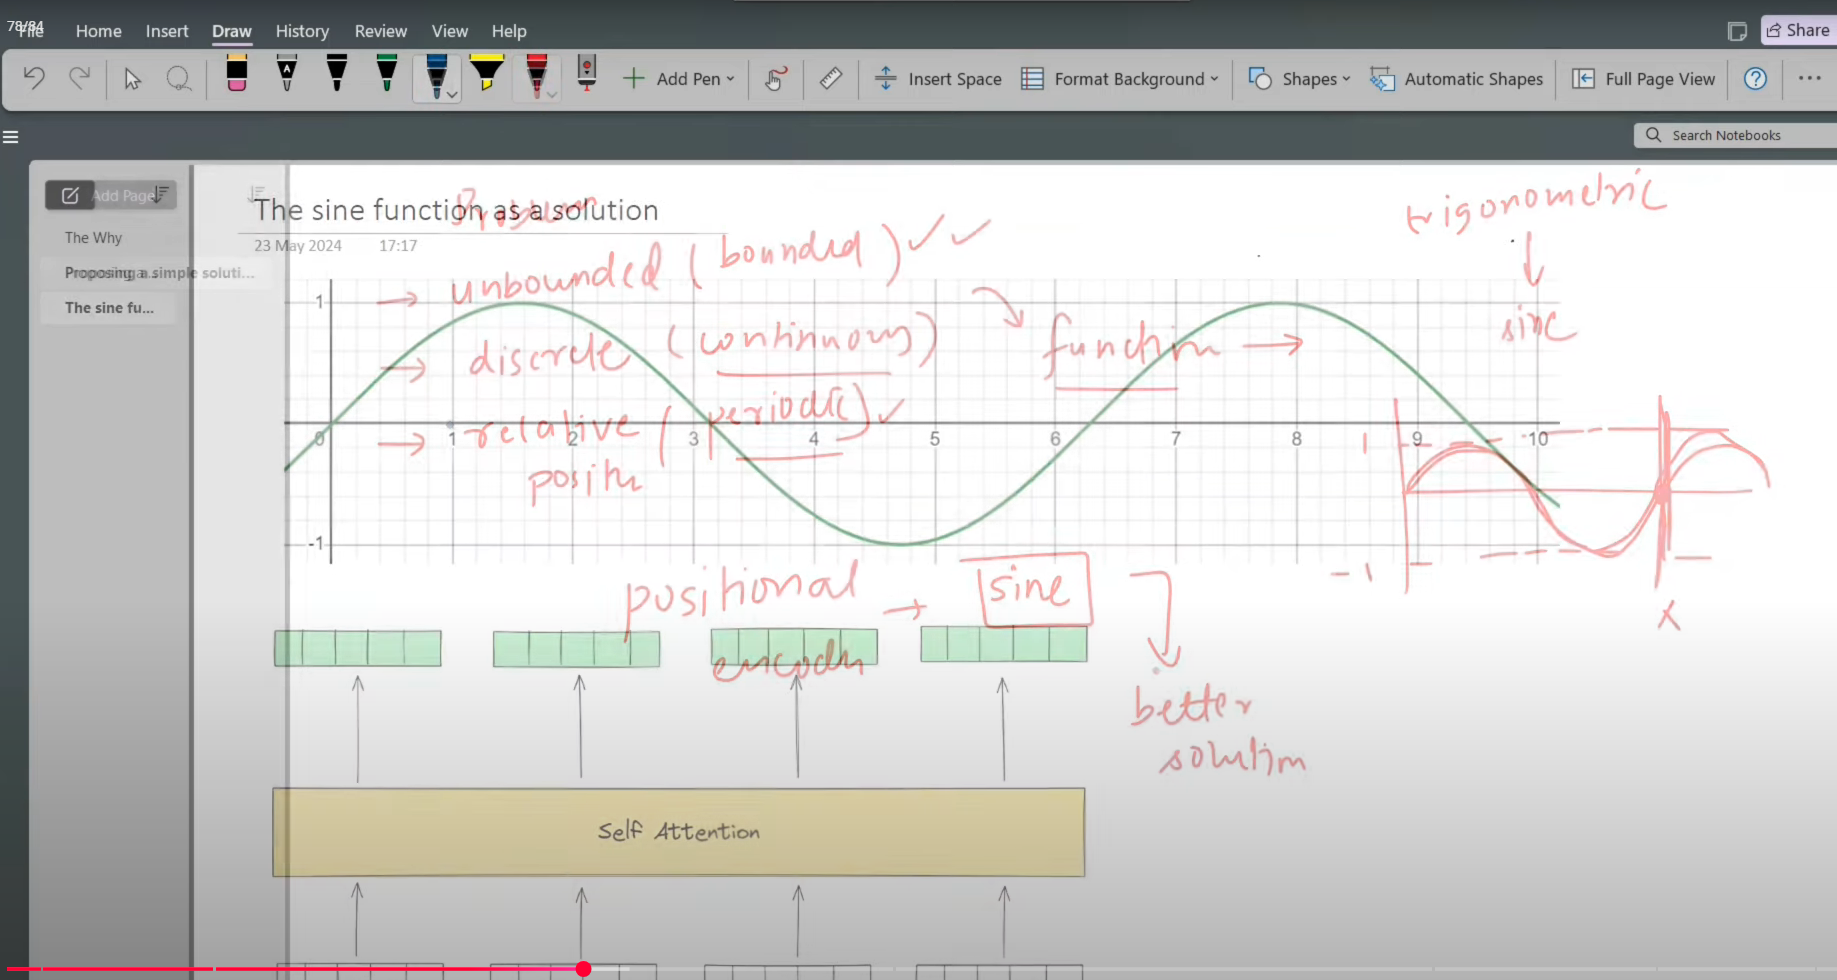

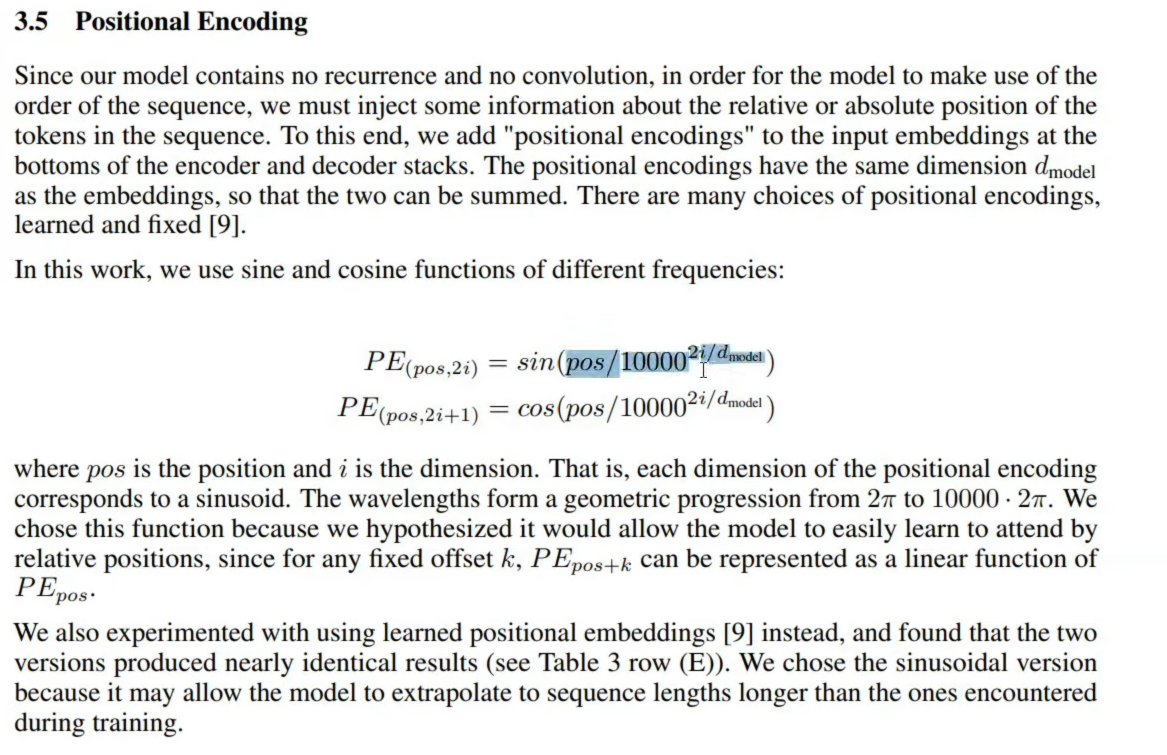

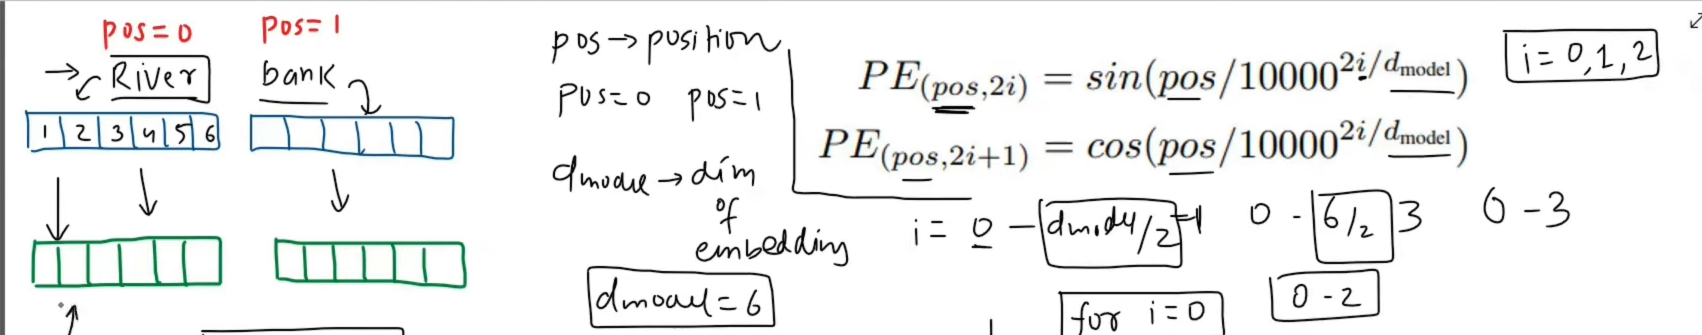

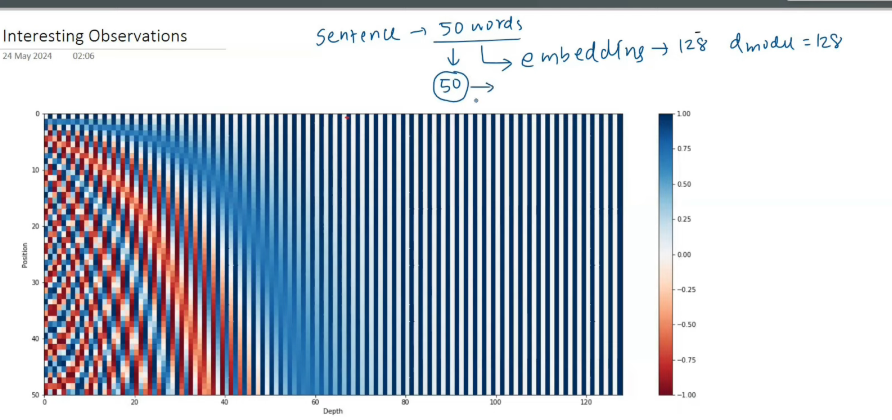

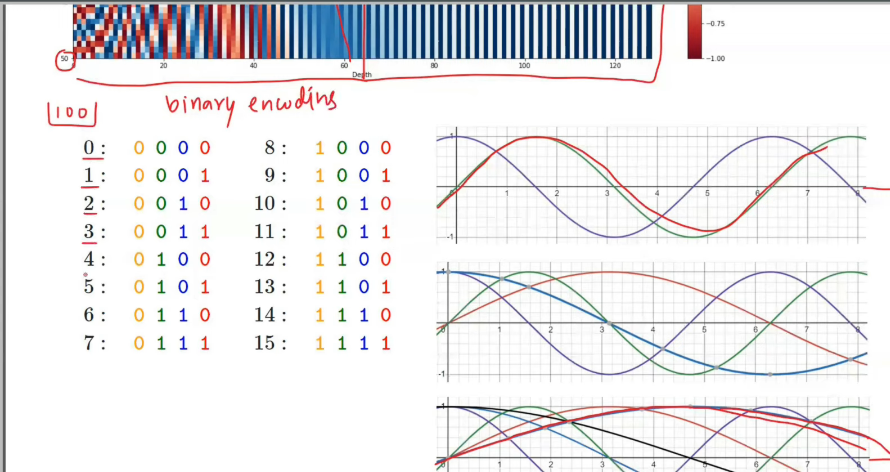

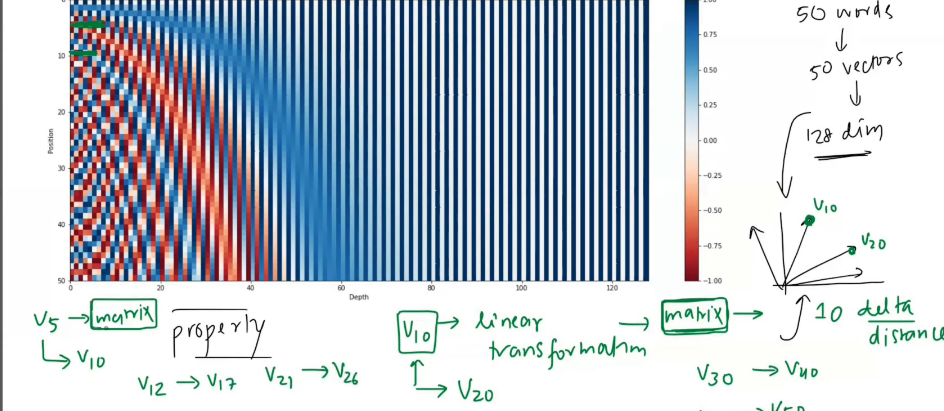

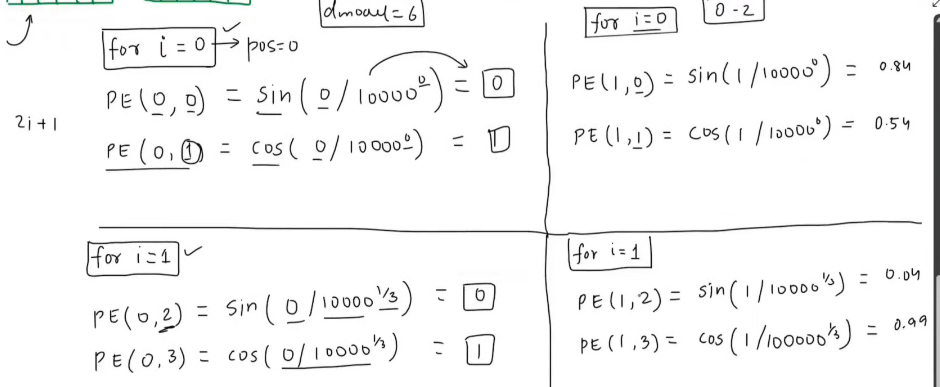

Positional Encoding is a crucial component of the Transformer architecture that addresses a significant limitation of its self-attention mechanism.

### Summary of Positional Encoding
Positional Encoding is a technique used in Transformer models to **inject information about the relative or absolute position of words in a sequence**. This is essential because the self-attention mechanism, which allows parallel processing of all words, inherently lacks an understanding of word order. Without positional encoding, a Transformer would treat sentences like "Nitish killed lion" and "Lion killed Nitish" as identical, despite their completely different meanings. Positional encoding provides this missing order information, ensuring that the model understands where words are located within a sentence.

### Why Positional Encoding is Done
The need for positional encoding arises from the parallel processing nature of the self-attention module in Transformers:
*   **Self-Attention's Parallelism:** Self-attention can generate contextual embeddings for all words in a sentence simultaneously, which is a major benefit for processing large documents quickly. It doesn't matter if a sentence has two words or 10,000 words; all contextual embeddings can be generated in parallel.
*   **Loss of Order Information:** While parallelism offers speed, its major drawback is that **it cannot capture the order of words**. When all words are sent to the self-attention module at once, it has no mechanism to determine which word came first or last. For the self-attention module, "Nitish killed lion" and "Lion killed Nitish" are identical because it receives the same set of words.
*   **Contrast with RNNs:** Recurrent Neural Networks (RNNs) inherently handle word order because they process words sequentially, one by one. For an RNN, "Nitish killed lion" would be processed by sending "Nitish" first, then "killed," then "lion," making the order evident.
*   **Importance of Word Order in NLP:** In Natural Language Processing (NLP) applications, word order is paramount as it completely changes the meaning of sentences. Without a mechanism to understand this order, Transformers would be ineffective for real-world NLP tasks.
*   **Solution:** Positional encoding is the logic designed to **encode this order information into the Transformer's self-attention module**.

### Steps Done in Positional Encoding

The development of positional encoding, as explained in the source, follows a "first principles" approach, starting with basic ideas and refining them:

1.  **Initial Simple Solution: Counting**
    *   **Idea:** Assign a simple count (1, 2, 3, 4, ...) to each word based on its position in the sentence.
    *   **Integration:** This number would be appended as an additional dimension to the word's embedding vector. For example, a 512-dimension embedding would become 513 dimensions.
    *   **Problems identified:**
        *   **Unbounded Values:** As sentence length increases, the positional numbers can become very large (e.g., 100,000 for a long document), which Neural Networks (NNs) dislike due to issues like vanishing or exploding gradients during backpropagation.
        *   **Normalization Issues:** Normalizing these counts (e.g., dividing by total words) leads to inconsistent positional values for the same position across different sentences (e.g., the second word in a two-word sentence might get '1', while the second word in a four-word sentence might get '0.5'), confusing the NN.
        *   **Discrete Values:** Counting produces discrete numbers, whereas NNs generally prefer smooth, continuous transitions for better numerical stability and gradient flow.
        *   **Inability to Capture Relative Position:** A simple count cannot easily represent the *distance* or *relative position* between words (e.g., how far "the" is from "Nitish") because the output is discrete.

2.  **Second Solution: Using a Single Trigonometric Function (Sine Curve)**
    *   **Idea:** Replace discrete counts with values from a continuous, bounded, and periodic function like `sin(position)`. The sine function's y-values are always between -1 and 1 (bounded), it's continuous, and its pattern repeats (periodic).
    *   **Integration:** The `sin(position)` value would be calculated for each word and appended to its embedding.
    *   **Benefits:** Solves the unbounded values and discrete values problems, and has the potential to capture relative positions (explained later).
    *   **Problem identified:**
        *   **Non-Unique Values due to Periodicity:** The periodic nature of sine means that the same positional encoding value (y-value) will eventually repeat for different word positions (x-values), leading to non-unique encodings for unique positions. This would confuse the model, making it perceive different positions as the same.

3.  **Third Solution: Using Sine and Cosine Pairs with Varying Frequencies**
    *   **Idea:** To overcome the non-uniqueness problem, instead of a single scalar value, each word's position is represented by a **vector**. This vector is generated using **pairs of sine and cosine functions**.
    *   **Initial Step:** For each word, calculate both `sin(position)` and `cos(position)`. These two values form a 2-dimensional positional encoding vector.
    *   **Scaling Up:** To further reduce the probability of duplicate vectors, additional sine-cosine pairs are introduced. Each subsequent pair uses a **different, generally lower, frequency**. For example, `sin(pos/2)` and `cos(pos/2)`, then `sin(pos/3)` and `cos(pos/3)`, and so on. This effectively increases the dimensionality of the positional encoding vector.
    *   **Analogy to Binary Encoding:** This approach is analogous to binary encoding but in the domain of continuous numbers. Lower dimensions (high-frequency curves) change rapidly, similar to low-order bits, while higher dimensions (low-frequency curves) change slowly, like high-order bits.

4.  **The "Attention Is All You Need" (Transformer) Solution**
    *   **Positional Encoding Vector:** For every word, a positional encoding is generated as a vector.
    *   **Dimension Matching:** The **dimension of the positional encoding vector is exactly the same as the dimension of the word embedding vector**. For instance, if word embeddings are 6-dimensional, the positional encoding vector will also be 6-dimensional.
    *   **Combination with Embeddings: Addition:** Instead of concatenating the positional encoding vector with the word embedding (which would double the dimensions and increase training parameters/time), the two vectors are **added element-wise**. The resulting combined vector contains information from both the word embedding and its position, and is then fed into the self-attention block.
    *   **Calculation of Vector Values:** For an *N*-dimensional positional encoding vector, *N/2* pairs of sine and cosine functions are used. For each pair, one dimension is filled with a sine value and the next with a cosine value. The frequency of these sine/cosine waves systematically decreases as `i` (the dimension index) increases.

### Mathematics Included and Each Term's Significance

The original "Attention Is All You Need" paper provides the following formulas for calculating positional encodings:

*   For even dimensions: `PE(pos, 2i) = sin(pos / (10000^(2i/d_model)))`
*   For odd dimensions: `PE(pos, 2i+1) = cos(pos / (10000^(2i/d_model)))`

Let's break down each term:

*   **`pos` (Position of the word):**
    *   **Significance:** This is the **absolute position (index) of the word** within the sequence.
    *   **Example:** For "River Bank," "River" would have `pos = 0`, and "Bank" would have `pos = 1`. If there was a third word, its `pos = 2`, and so on.

*   **`d_model` (Dimension of embeddings):**
    *   **Significance:** This represents the **dimension of the word embedding vectors**. Crucially, the positional encoding vector will have the same `d_model` dimensions.
    *   **Example:** If your word embeddings are 6-dimensional, `d_model = 6`. In the original paper, `d_model = 512`.

*   **`i` (Index of the dimension):**
    *   **Significance:** This index **ranges from 0 up to `d_model/2 - 1`**. It is used to select which pair of dimensions (2i and 2i+1) is being calculated. For each `i`, a sine and a cosine function are used for a pair of dimensions.
    *   **Example:** If `d_model = 6`, then `i` will take values `0`, `1`, and `2`.
        *   `i = 0` calculates `PE(pos, 0)` using `sin` and `PE(pos, 1)` using `cos`.
        *   `i = 1` calculates `PE(pos, 2)` using `sin` and `PE(pos, 3)` using `cos`.
        *   `i = 2` calculates `PE(pos, 4)` using `sin` and `PE(pos, 5)` using `cos`.

*   **`10000^(2i/d_model)` (Frequency term):**
    *   **Significance:** This entire term controls the **frequency (or wavelength) of the sine and cosine waves**. As `i` increases, the exponent `2i/d_model` increases, making the denominator larger. A larger denominator means the argument of the sine/cosine function `pos / (frequency_term)` changes more slowly, resulting in a **lower frequency wave**.
    *   **Effect:** This creates a set of sine and cosine waves with **different frequencies**, ranging from high frequency for lower `i` values (early dimensions) to low frequency for higher `i` values (later dimensions). This varying frequency is what allows the unique encoding for each position and helps capture relative positions.

### Capturing Relative Positions
One of the crucial advantages of this trigonometric positional encoding method is its ability to **capture relative positions**, a problem that the simple counting method failed to address.

*   **The "Mind-Blowing" Property:** The sine/cosine-based positional encodings possess a remarkable property: for any given "delta" (distance between two words, e.g., 10 positions apart), there exists a **linear transformation (a matrix multiplication)**. If you apply this specific matrix to the positional encoding vector of a word, it will automatically transform it into the positional encoding vector of a word that is *delta* positions away. For example, a matrix for a delta of 10 can transform the positional encoding of word 10 to word 20, or word 30 to word 40, and so on.
*   **Implication:** This means the system **inherently understands the distance or relative positions between words**. This intelligence is not explicitly programmed but emerges from the mathematical properties of sine and cosine functions.
*   **Mathematical Basis:** The linear transformation matrix itself contains both sine and cosine components. This is a primary reason why sine and cosine functions are used as a pair in positional encoding; their combined mathematical properties facilitate the capture of relative distances.

In essence, positional encoding is a clever way to encode discrete position information into continuous, bounded, and unique vectors that also implicitly understand the relative distances between words, enabling the Transformer to correctly interpret word order in language.



### Q1: Why is Positional Encoding used in the Transformer architecture?

**A1:** Positional Encoding is essential in Transformers because its core component, the **self-attention mechanism, inherently loses information about the order of words** in a sequence.

*   **Parallel Processing of Self-Attention:** The self-attention module's major benefit is its ability to generate contextual embeddings for all words in a sentence *simultaneously* (in parallel). This makes processing large documents, like a 10,000-word PDF, very fast because all 10,000 contextual embeddings can be generated at once.
*   **Loss of Order Information:** However, this parallel processing means that the self-attention module receives all words at the same time and has **no mechanism to understand their sequence or order**. For example, for self-attention, the sentences "Nitish killed lion" and "Lion killed Nitish" would be treated as identical because they contain the same set of words, even though their meanings are completely different due to word order.
*   **Contrast with RNNs:** Traditional Recurrent Neural Networks (RNNs) naturally handle word order by processing words *sequentially* (one by one). An RNN would process "Nitish," then "killed," then "lion," making the order explicit. However, RNNs are slow for long sequences because of this sequential nature.
*   **Importance of Word Order in NLP:** In Natural Language Processing (NLP) applications, word order is critical for determining the meaning of a sentence. Without understanding word order, Transformers would be ineffective for real-world NLP tasks.
*   **The Solution:** Positional Encoding is the specific logic designed to **inject this crucial order information into the Transformer's self-attention module**, ensuring the model knows the position of each word within the sentence.

### Q2: What alternative approaches to Positional Encoding were considered, and why were they rejected?

**A2:** The development of the final positional encoding solution involved a "first principles" approach, starting with simpler ideas and progressively refining them as problems were identified.

**Alternative 1: Simple Counting (Appending an Integer Position)**
*   **Idea:** Assign a simple, increasing integer (e.g., 1, 2, 3, 4, ...) to each word based on its position in the sentence. This number would be appended as an additional dimension to the word's embedding vector.
*   **Reasons for Rejection:**
    *   **Unbounded Values:** For long documents (e.g., a book with 100,000 words), the last word's position could be a very large number (e.g., 100,000). Neural Networks (NNs) generally dislike such large, unbounded numbers because they can cause **numerical instability during training, leading to issues like vanishing or exploding gradients**.
    *   **Normalization Issues:** Normalizing these counts to a fixed range (e.g., 0 to 1 by dividing by the total number of words) also proved problematic. The second word in a two-word sentence would get '1' (2/2), while the second word in a four-word sentence would get '0.5' (2/4). This **inconsistency for the same logical position across different sentences** would confuse the neural network.
    *   **Discrete Values:** Simple counting produces discrete numbers, whereas NNs generally **prefer smooth, continuous transitions** for better numerical stability and gradient flow.
    *   **Inability to Capture Relative Position:** This approach struggled to represent the *distance* or *relative position* between words. Since the output was discrete, the model couldn't easily infer how far apart two words were (e.g., the distance between position 1 and position 3).

**Alternative 2: Using a Single Trigonometric Function (Sine Curve)**
*   **Idea:** Replace discrete counts with values from a continuous, bounded, and periodic function like `sin(position)`. The sine function's y-values are always between -1 and 1 (bounded), it's continuous, and its pattern repeats (periodic). This value would be appended to the word's embedding.
*   **Benefits:** This solved the problems of unbounded values and discrete values identified with simple counting. It also had the potential to capture relative positions due to its periodic nature.
*   **Reason for Rejection:**
    *   **Non-Unique Values due to Periodicity:** The primary issue was that the periodic nature of the sine curve means that **the same output value (y-value) will eventually repeat for different input positions (x-values)**. If two different word positions have the same positional encoding value, the model would get confused, perceiving them as the same position despite being distinct. For example, `sin(3)` might be similar to `sin(35)`, leading the model to believe the 3rd and 35th words are at the same position.

### Q3: What are the major reasons for the final design of Positional Encoding, including analogies?

**A3:** The final design, as proposed in the "Attention Is All You Need" paper, builds upon the previous attempts by using **pairs of sine and cosine functions with varying frequencies, which are then added to the word embeddings**.

*   **Solving Non-Uniqueness with Sine and Cosine Pairs:** To overcome the problem of non-unique values from a single sine function, the solution uses **pairs of sine and cosine functions** for each position. Instead of a single scalar, each word's position is represented by a **vector**. To further ensure uniqueness across very long sequences, additional sine-cosine pairs are used, with each subsequent pair having a **different, systematically decreasing frequency**. This effectively increases the dimensionality of the positional encoding vector, making it highly improbable for two different positions to have the exact same encoding vector.
*   **Dimension Matching and Element-wise Addition:**
    *   For every word, the positional encoding is generated as a **vector**.
    *   The **dimension of this positional encoding vector is precisely the same as the dimension of the word embedding vector** (e.g., if word embeddings are 6-dimensional, the positional encoding vector is also 6-dimensional).
    *   Instead of concatenating the positional encoding vector with the word embedding (which would double the dimensions), the two vectors are **added element-wise**. The resulting combined vector contains both the word's meaning and its position, and is then fed into the self-attention block.
    *   **Reason for Addition over Concatenation:** Concatenation would double the input dimensions to the self-attention module, directly leading to an **increase in the number of model parameters and significantly extending training time**. Adding the vectors avoids this increase in parameters and training cost.
*   **The Mathematical Formula and Varying Frequencies:**
    *   The specific formulas used are:
        *   `PE(pos, 2i) = sin(pos / (10000^(2i/d_model)))` (for even dimensions)
        *   `PE(pos, 2i+1) = cos(pos / (10000^(2i/d_model)))` (for odd dimensions)
    *   Here:
        *   `pos` is the absolute position of the word (e.g., 0, 1, 2, ...).
        *   `d_model` is the dimension of the word embeddings.
        *   `i` is the index for a pair of dimensions, ranging from `0` to `d_model/2 - 1`.
        *   The term `10000^(2i/d_model)` is critical. As `i` increases (moving to higher dimensions in the positional encoding vector), this term acts as a larger denominator, resulting in **lower frequency waves**. Conversely, lower `i` values (earlier dimensions) correspond to higher frequency waves. This systematic variation in frequency across dimensions is key to the encoding's effectiveness.
*   **Analogy to Binary Encoding:** This approach is analogous to **binary encoding but applied in the domain of continuous numbers**.
    *   In binary encoding, lower-order bits change rapidly (e.g., 010101...), while higher-order bits change slowly (e.g., 00001111...).
    *   Similarly, in positional encoding, the **lower dimensions (corresponding to high-frequency waves) change rapidly** for small changes in position, providing fine-grained information. The **higher dimensions (corresponding to low-frequency waves) change slowly**, providing more coarse-grained information that is robust across longer distances. This continuous "binary-like" representation allows for a unique and rich encoding for each position.
*   **Capturing Relative Positions (The "Mind-Blowing" Property):** This design enables the Transformer to **easily learn to attend by relative positions**.
    *   The combination of sine and cosine functions with varying frequencies has a remarkable mathematical property: for any fixed positional offset (or "delta," representing the distance between two words), there exists a **linear transformation (a specific matrix multiplication)** that can take the positional encoding vector of one word and transform it into the positional encoding vector of another word that is *exactly that delta* positions away.
    *   This linear transformation matrix is constant for a given offset and *does not depend on the absolute position* of the words. This means the model inherently understands the distance and relative relationship between words, a capability missing from simpler approaches.
    *   The presence of both sine and cosine components in the positional encoding is crucial for this property, as the **linear transformation matrix itself contains both sine and cosine elements**, making this mathematical relationship possible.

### Q4: Why is such a detailed explanation of "all these things" (steps, alternatives, math) needed?

**A4:** A detailed and gradual explanation of positional encoding is crucial for several reasons:

*   **Importance of the Concept:** Positional encoding is a **very important aspect of Transformers**, even though it's often overlooked or quickly explained in general overviews.
*   **Complexity of Understanding:** The concept is perceived as **"a bit difficult to understand"**. A direct, high-level explanation might not convey its depth and necessity effectively.
*   **First Principles Approach:** By using a "first principles" approach—starting with basic ideas, identifying their problems, and gradually refining them—the explanation becomes **simplified and easier to grasp**, akin to inventing the solution from scratch. This progressive buildup helps the learner appreciate *why* the final, more complex solution is necessary.
*   **Deeper Understanding and Appreciation:** Understanding the problems with simpler alternatives (like unbounded values, discrete nature, and inability to capture relative positions) highlights the brilliance and necessity of the final design. The detailed breakdown of the mathematical formulas, including the role of `pos`, `d_model`, `i`, and the `10000^(2i/d_model)` frequency term, explains *how* the unique and relative position-capturing properties actually emerge.
*   **Unveiling "Mind-Blowing" Properties:** The detailed explanation uncovers sophisticated properties, such as the **implicit understanding of relative positions through linear transformations**. This kind of insight goes beyond mere memorization and sparks curiosity, making the "math a beautiful thing". Without this detail, these powerful underlying mechanisms would remain a "black box".
*   **Avoiding Superficial Knowledge:** Many resources might explain positional encoding in "two-three lines," but a deep dive is required to avoid a superficial understanding and to truly appreciate the engineering and mathematical elegance behind it.


---

### **1. What is Positional Encoding?**

Transformers are **sequence models** (like RNNs or LSTMs) but **they do not process tokens sequentially**. Instead, they use **self-attention**, which looks at all tokens simultaneously.

The problem:

* Self-attention has **no inherent sense of order**.
* Without knowing positions, the model can’t distinguish `"The cat sat on the mat"` from `"On the mat sat the cat"`.

**Solution:**
We add **positional encodings** to the input embeddings to give the model a sense of order.

Mathematically, if the token embedding is $x_i$ at position $i$, the input to the Transformer is:

$$
z_i = x_i + PE(i)
$$

Where $PE(i)$ is the positional encoding vector.

---

### **2. How Positional Encoding is Done (Original Transformer)**

The original paper (Vaswani et al., 2017) used **sinusoidal functions**:

$$
PE_{(pos, 2i)} = \sin \left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE_{(pos, 2i+1)} = \cos \left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

* $pos$ = token position
* $i$ = dimension index
* $d_{model}$ = embedding dimension

**Intuition:**

* Encodes position in a **continuous space**.
* Allows model to **generalize to longer sequences** than seen in training because sine/cosine can extrapolate.

---

### **3. Why We Need Positional Encoding**

Without it:

* Transformer **loses order information**.
* For example, `"I love AI"` and `"AI love I"` would look identical to self-attention.

Positional encodings **inject order info** into the token embeddings so attention can consider both **content** and **position**.

---

### **4. Problems with Original Approach**

1. **Fixed nature**: Sinusoidal encoding is **not learned**, so it may not always capture the best position representation for the task.
2. **Limited flexibility**: Some tasks need **relative positions** rather than absolute positions.

   * Example: "The word two tokens before X" → absolute positional encoding doesn’t help directly.
3. **Generalization issue**: While sinusoidal encoding can theoretically generalize, in practice, learned or relative encodings sometimes perform better.

---

### **5. Alternative Approaches**

1. **Learned Positional Embeddings**

   * Treat position as a trainable vector (like a token embedding).
   * Pros: More flexible, can adapt to task-specific patterns.
   * Cons: Might **not generalize to longer sequences** unseen in training.

2. **Relative Positional Encoding** (used in Transformer-XL, T5, and other models)

   * Instead of encoding absolute positions, encode **distance between tokens**.
   * Pros: Better at capturing **local dependencies**, more natural for certain tasks.

3. **Rotary Positional Embeddings (RoPE)**

   * Rotates query/key vectors based on position.
   * Pros: Simple, works well for long context modeling.

---

✅ **Summary Table**

| Aspect             | Original (Sinusoidal) | Learned   | Relative  | RoPE     |
| ------------------ | --------------------- | --------- | --------- | -------- |
| Fixed or learnable | Fixed                 | Learnable | Learnable | Fixed    |
| Absolute/Relative  | Absolute              | Absolute  | Relative  | Relative |
| Generalization     | Good                  | Poor      | Good      | Good     |
| Complexity         | Low                   | Low       | Medium    | Medium   |

---

So in short:

* **Positional encoding is needed** because Transformers are permutation-invariant.
* **Original method**: sinusoidal absolute encoding.
* **Problems**: limited flexibility, sometimes suboptimal for long sequences or relative positions.
* **Alternatives**: learned embeddings, relative positional encoding, rotary embeddings.

---




---

### 1. **Positional Encoding in Transformers**

The Transformer injects positional information into token embeddings because self-attention itself is **permutation-invariant**. The encoding is defined as:

$$
PE_{(pos, 2i)} = \sin\Big(\frac{pos}{10000^{2i/d_\text{model}}}\Big), \quad
PE_{(pos, 2i+1)} = \cos\Big(\frac{pos}{10000^{2i/d_\text{model}}}\Big)
$$

where:

* $pos$ is the position in the sequence,
* $i$ indexes the dimension of the embedding,
* $d_\text{model}$ is the embedding size.

These sine and cosine functions encode **different frequencies**, allowing the model to distinguish positions.

---

### 2. **The Claim**

The paper states that there exists a **linear transformation $W$** such that:

$$
PE_{pos+k} = W^k \, PE_{pos}
$$

for any offset $k$. Intuitively, this means the encoding at a position relative to another can be represented by a linear operation — crucial for the model to attend to **relative positions** efficiently.

---

### 3. **Constructing the Linear Transformation**

Define a **matrix $W$** that rotates pairs of sine and cosine components:

$$
W = \begin{bmatrix} R_0 & & 0 \\ & \ddots & \\ 0 & & R_{d/2-1} \end{bmatrix}, \quad
R_i = \begin{bmatrix} \cos(\omega_i) & -\sin(\omega_i) \\ \sin(\omega_i) & \cos(\omega_i) \end{bmatrix}, \quad
\omega_i = \frac{1}{10000^{2i/d}}
$$

* Each $R_i$ is a 2×2 rotation matrix for the corresponding frequency.
* $W^k$ rotates the sine-cosine pairs by $k$ steps, corresponding to a shift in position.

---

### 4. **Using Trigonometric Addition Formulas**

For a given position $pos$ and offset $k$:

$$
\sin(\omega_i(pos + k)) = \sin(\omega_i pos) \cos(\omega_i k) + \cos(\omega_i pos) \sin(\omega_i k)
$$

$$
\cos(\omega_i(pos + k)) = \cos(\omega_i pos) \cos(\omega_i k) - \sin(\omega_i pos) \sin(\omega_i k)
$$

This shows that **adding an offset in position is equivalent to applying a linear rotation**:

$$
\begin{bmatrix} \sin(\omega_i(pos+k)) \\ \cos(\omega_i(pos+k)) \end{bmatrix} = R_i^k \begin{bmatrix} \sin(\omega_i pos) \\ \cos(\omega_i pos) \end{bmatrix}
$$

---

### 5. **Conclusion**

By stacking all $R_i$ matrices along the diagonal, the **entire positional encoding vector** satisfies:

$$
PE_{pos+k} = W^k \, PE_{pos}
$$

* $W^k$ depends **only on the offset $k$ and the frequency $\omega_i$**, not on the absolute position $pos$.
* This proves that **relative positions can be learned linearly**, exactly what Vaswani et al. hypothesized.

---

**Key Insight:** The sine-cosine construction allows **shifts in position to be expressed as linear operations**. This is why the Transformer can easily attend based on relative positions without explicitly learning them from scratch.

---






---

### 1. **Why we need positional encoding**

Transformers don’t know the order of words on their own — the attention mechanism treats every word equally.
So we **add extra numbers (positional encodings) to tell the model the position of each word**.

---

### 2. **How positional encoding is defined**

For each position in the sentence, we calculate a vector using **sine and cosine functions**:

* One part uses sine: `sin(position × some frequency)`
* Another part uses cosine: `cos(position × some frequency)`

Different “frequencies” are used in different dimensions of the vector, so each position gets a **unique pattern**.

---

### 3. **The cool property**

The Transformer paper says:

> “There exists a **linear transformation** that can shift the encoding from one position to another.”

In plain words: **you can get the encoding of a word 3 positions ahead by just applying a fixed linear operation to the current position’s encoding.**

---

### 4. **Why this works: the math behind it**

Sine and cosine have a neat property called the **angle addition formula**:

$$
\sin(a + b) = \sin(a)\cos(b) + \cos(a)\sin(b)  
\cos(a + b) = \cos(a)\cos(b) - \sin(a)\sin(b)
$$

This means **shifting the position by a fixed number (b)** is just a **rotation of the sine-cosine pair**.

* Think of `(sin, cos)` as a 2D point on a circle.
* Moving from one position to another is like **rotating this point around the circle**.
* Rotation is a **linear operation** — that’s why it works!

---

### 5. **Key idea**

* Positional encoding = a bunch of sine and cosine values.
* Shifting positions = rotating those values.
* Rotation = linear transformation.
* Therefore, the model can handle relative positions using a simple linear operation.

---

